# Hotel ADR Regression — Tree / Kernel / Distance-Based Models
Algorithms 6–10 of the capstone regression comparison, run on a **5,000-row sample**
of `hotel_bookings_cleaned.csv` (not the full 87,394 rows) so every cell finishes in
seconds instead of minutes. Each algorithm is one self-contained cell: run top to
bottom and every cell prints its own metrics immediately.

| # | Algorithm | Focus |
|---|-----------|-------|
| 6 | Decision Tree Regressor | Tune `max_depth`; show feature importance |
| 7 | Random Forest Regressor | Ensemble baseline; tune `n_estimators` |
| 8 | Gradient Boosting Regressor | sklearn GBM; tune `learning_rate` |
| 9 | Support Vector Regressor (SVR) | Scale features first; tune `C` and `kernel` |
| 10 | K-Nearest Neighbors Regressor | Tune `k`; discuss impact of scaling |


In [1]:
# Setup: imports, load data, sample, split, build the shared preprocessor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Load & sample ----
# NOTE: the dataset is loaded as "hotel_bookings_cleaned.csv" (the cleaned hotel
# bookings file used throughout this project). Update DATA_PATH if your file is
# named differently, e.g. "hotel_cleaned_reviews.csv".
DATA_PATH = "hotel_bookings_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print("Full dataset shape:", df.shape)

SAMPLE_SIZE = 5000  # a few thousand rows instead of all ~87k, for fast iteration
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print("Sample used for these 5 models:", df_sample.shape)

# ---- Target / features ----
y = df_sample["adr"]
X = df_sample.drop(columns=[
    "adr",                     # target
    "reservation_status",      # outcome, leaks the label
    "reservation_status_date", # outcome, leaks the label
    "is_canceled",             # outcome, leaks the label
])

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
print(f"{len(categorical_cols)} categorical columns, {len(numerical_cols)} numerical columns")

# ---- Train / test split (shared by every algorithm below) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# ---- Preprocessors ----
# Tree-based models don't need scaling: one-hot the categories, pass numerics through.
preprocessor_unscaled = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numerical_cols),
])

# Distance/margin-based models (SVR, KNN) need scaled numerics.
preprocessor_scaled = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols),
])

# Collect every model's headline metrics here so the final cell can compare them.
results = []

def evaluate_and_record(name, model, X_te, y_te):
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    results.append({"Algorithm": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name}")
    print("-" * len(name))
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.4f}")
    return pred


Full dataset shape: (87394, 37)
Sample used for these 5 models: (5000, 37)
10 categorical columns, 23 numerical columns
Train: (4000, 33)  Test: (1000, 33)


/tmp/ipykernel_128/3672869755.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


## 6. Decision Tree Regressor — tune `max_depth`, show feature importance

Best max_depth: {'model__max_depth': 10}
Best CV R²   : 0.5681

Decision Tree
-------------
MAE  : 23.260
RMSE : 37.325
R²   : 0.5044


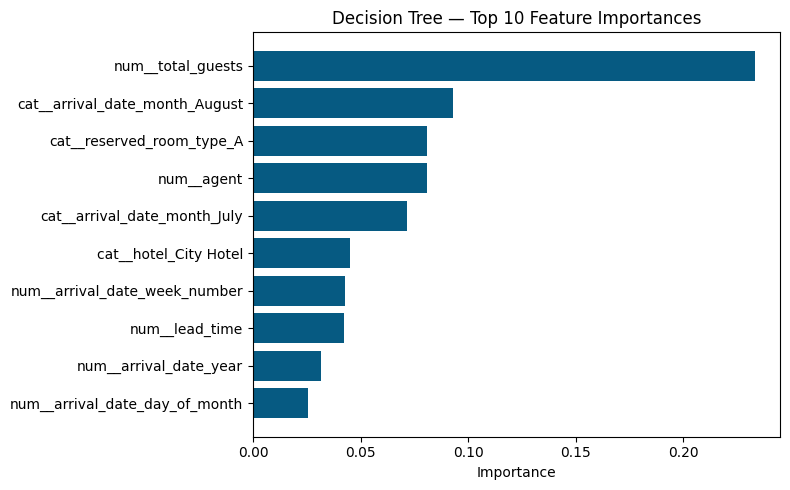

                       feature  importance
             num__total_guests    0.233206
cat__arrival_date_month_August    0.092979
     cat__reserved_room_type_A    0.080953
                    num__agent    0.080872
  cat__arrival_date_month_July    0.071631
         cat__hotel_City Hotel    0.044934
 num__arrival_date_week_number    0.042819
                num__lead_time    0.042168
        num__arrival_date_year    0.031682
num__arrival_date_day_of_month    0.025603


In [2]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", DecisionTreeRegressor(random_state=42)),
])

dt_params = {"model__max_depth": [3, 5, 7, 10, 15, None]}

dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=3, scoring="r2", n_jobs=-1)
dt_grid.fit(X_train, y_train)

print("Best max_depth:", dt_grid.best_params_)
print("Best CV R²   :", round(dt_grid.best_score_, 4))
print()

dt_pred = evaluate_and_record("Decision Tree", dt_grid, X_test, y_test)

# ---- Feature importance (top 10) ----
best_dt = dt_grid.best_estimator_
feature_names = best_dt.named_steps["preprocessor"].get_feature_names_out()
importances = best_dt.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#065A82")
plt.xlabel("Importance")
plt.title("Decision Tree — Top 10 Feature Importances")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))


## 7. Random Forest Regressor — ensemble baseline, tune `n_estimators`

In [3]:
from sklearn.ensemble import RandomForestRegressor

# Baseline: an untuned Random Forest, to see what the ensemble gets "for free"
# before any tuning, versus the single Decision Tree above.
rf_baseline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])
rf_baseline.fit(X_train, y_train)
print("Baseline Random Forest (default n_estimators=100)")
evaluate_and_record("Random Forest (baseline)", rf_baseline, X_test, y_test)
print()

# Tuned: sweep n_estimators to see how many trees the ensemble actually needs.
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rf_params = {"model__n_estimators": [50, 100, 150]}

rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring="r2", n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best n_estimators:", rf_grid.best_params_)
print("Best CV R²       :", round(rf_grid.best_score_, 4))
print()

rf_pred = evaluate_and_record("Random Forest (tuned)", rf_grid, X_test, y_test)


Baseline Random Forest (default n_estimators=100)
Random Forest (baseline)
------------------------
MAE  : 16.889
RMSE : 28.695
R²   : 0.7071



Best n_estimators: {'model__n_estimators': 150}
Best CV R²       : 0.7473

Random Forest (tuned)
---------------------
MAE  : 16.907
RMSE : 28.607
R²   : 0.7089


## 8. Gradient Boosting Regressor — tune `learning_rate`

In [4]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", GradientBoostingRegressor(n_estimators=100, random_state=42)),
])

gb_params = {"model__learning_rate": [0.01, 0.05, 0.1, 0.2]}

gb_grid = GridSearchCV(gb_pipeline, gb_params, cv=3, scoring="r2", n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Best learning_rate:", gb_grid.best_params_)
print("Best CV R²        :", round(gb_grid.best_score_, 4))
print()

gb_pred = evaluate_and_record("Gradient Boosting", gb_grid, X_test, y_test)


Best learning_rate: {'model__learning_rate': 0.2}
Best CV R²        : 0.7668

Gradient Boosting
-----------------
MAE  : 16.424
RMSE : 24.892
R²   : 0.7796


## 9. Support Vector Regressor (SVR) — scale features first, tune `C` and `kernel`

In [5]:
from sklearn.svm import SVR

# SVR is distance/margin based, so it needs the scaled preprocessor
# (unscaled numeric columns like lead_time or adr-adjacent counts would
# dominate the kernel purely because of their larger numeric range).
svr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVR()),
])

svr_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
}

svr_grid = GridSearchCV(svr_pipeline, svr_params, cv=3, scoring="r2", n_jobs=-1)
svr_grid.fit(X_train, y_train)

print("Best C / kernel:", svr_grid.best_params_)
print("Best CV R²     :", round(svr_grid.best_score_, 4))
print()

svr_pred = evaluate_and_record("SVR", svr_grid, X_test, y_test)


Best C / kernel: {'model__C': 10, 'model__kernel': 'linear'}
Best CV R²     : 0.6138



SVR
---
MAE  : 23.079
RMSE : 33.960
R²   : 0.5897


## 10. K-Nearest Neighbors Regressor — tune `k`, discuss impact of scaling
KNN predicts using distance between points, so unscaled numeric columns with
large ranges (e.g. `lead_time`, `agent`) would silently dominate the distance
calculation over small-range columns (e.g. `adults`, `is_family`). The cell
below tunes `k` on the **scaled** pipeline, then re-fits the same `k` on
**unscaled** data to show the R² gap scaling closes.

In [6]:
from sklearn.neighbors import KNeighborsRegressor

# ---- Tuned KNN on SCALED features ----
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", KNeighborsRegressor()),
])

knn_params = {"model__n_neighbors": [3, 5, 7, 9, 11, 15]}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=3, scoring="r2", n_jobs=-1)
knn_grid.fit(X_train, y_train)

best_k = knn_grid.best_params_["model__n_neighbors"]
print("Best k (scaled features):", best_k)
print("Best CV R²              :", round(knn_grid.best_score_, 4))
print()

knn_pred = evaluate_and_record(f"KNN (k={best_k}, scaled)", knn_grid, X_test, y_test)

# ---- Same k, but on UNSCALED features, to show why scaling matters for KNN ----
knn_unscaled = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", KNeighborsRegressor(n_neighbors=best_k)),
])
knn_unscaled.fit(X_train, y_train)
print()
print(f"Same k={best_k}, UNSCALED features (for comparison only — not added to the leaderboard)")
unscaled_pred = knn_unscaled.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, unscaled_pred):.3f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, unscaled_pred)):.3f}")
print(f"R²   : {r2_score(y_test, unscaled_pred):.4f}")
print()
print("→ Scaling changes the R² meaningfully: without it, large-range numeric")
print("  columns dominate the distance metric and the neighbor structure is distorted.")


Best k (scaled features): 11
Best CV R²              : 0.4612

KNN (k=11, scaled)
------------------
MAE  : 26.502
RMSE : 37.725
R²   : 0.4938

Same k=11, UNSCALED features (for comparison only — not added to the leaderboard)


MAE  : 32.458
RMSE : 44.402
R²   : 0.2987

→ Scaling changes the R² meaningfully: without it, large-range numeric
  columns dominate the distance metric and the neighbor structure is distorted.


## Comparison — all 5 algorithms on the same 5,000-row sample

               Algorithm     MAE    RMSE     R2
       Gradient Boosting 16.4243 24.8922 0.7796
   Random Forest (tuned) 16.9073 28.6070 0.7089
Random Forest (baseline) 16.8888 28.6955 0.7071
                     SVR 23.0789 33.9601 0.5897
           Decision Tree 23.2599 37.3246 0.5044
      KNN (k=11, scaled) 26.5020 37.7246 0.4938


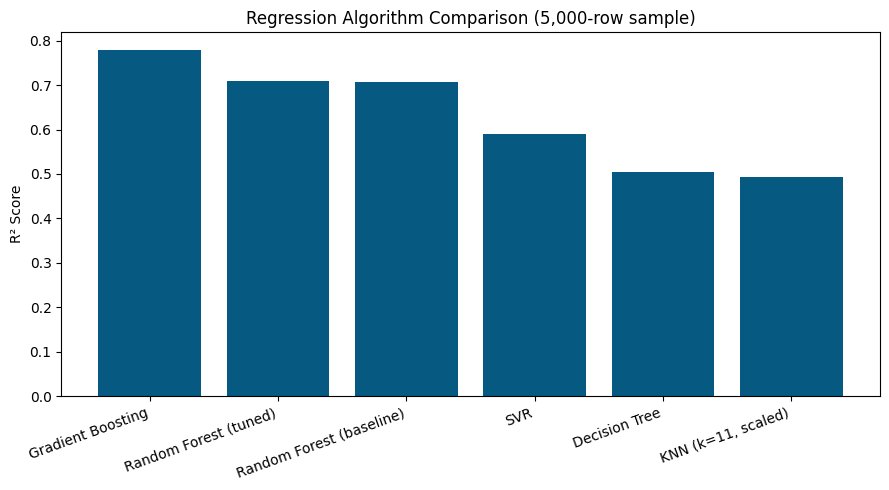

In [7]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df.round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.bar(results_df["Algorithm"], results_df["R2"], color="#065A82")
plt.ylabel("R² Score")
plt.title("Regression Algorithm Comparison (5,000-row sample)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
